In [ ]:
"""ML"""
import torch
import torch.nn.functional as F
import numpy as np

"""Visualization"""
from matplotlib import pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)          
pd.set_option('display.max_colwidth', None)   

"""Dataset and Preprocessing"""
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

"""Utils"""
# Add Base directory to Python path
import sys
import os
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Utils.paths import *
import Utils.plotting as plotting
import Utils.arch_logging as arch_logging
import Utils.json_inter as json_inter
from Utils.plotting import plot_metrics
from Assets.Models.Models import *

import copy
from tqdm import tqdm

"""Logger"""
from Logger import *
logger = Logger(f"{LOGS}\\training.log", f"{LOGS}\\.sesh")

torch.manual_seed(0)
np.random.seed(0)

%load_ext autoreload
%autoreload 2

torch.__version__, np.__version__

Logger initialized with file D:\Repos\FPGA_Radar_Microdoppler_Classification\Logs\training.log, default tag [DEF] and level [INFO]
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('2.5.1+cu118', '2.0.1')

In [38]:
json_inter.load_config_as_dataframe("preprocess_metadata.json", fillna_with="N/A")

,run_id,window_size,stride,snr_threshold,test_size,val_size,random_seed,balance_classes,dataset_name,file_name,timestamp,doppler_bins,correlation_threshold,max_lag,size,file_path,augmentations.use_augmentation,augmentations.aug_amp_scale,augmentations.aug_noise,augmentations.aug_noise_std,augmentations.aug_time_shift,augmentations.aug_time_shift_max,augmentations.aug_freq_shift,augmentations.aug_freq_shift_max,REMARKS
0,open_radar_K128_S32_SNR3.0_002,128,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K128_S32_SNR3.npz,2026-02-23 13:45:53,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,open_radar_K64_S32_SNR3.0_003,64,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K64_S32_SNR3.npz,2026-02-23 13:54:47,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,open_radar_K256_S32_SNR3.0_004,256,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K256_S32_SNR3.npz,2026-02-23 13:58:14,1008.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,004,128,42,N/A,0.1,0.1,42,N/A,radar_windows_corr_stride,dataset,2026-02-24 19:50:38,1008.0,0.25,512.0,4.60 GB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,005,128,42,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 20:17:44,1008.0,0.25,512.0,1.499 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K128_S42.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
5,006,64,42,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:25:22,1008.0,0.25,512.0,0.8329 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K64_S42.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
6,007,32,32,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:40:52,1008.0,0.25,512.0,0.576 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S32.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
7,008,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:44:38,1008.0,0.25,512.0,1.1336 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
8,009,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 22:41:20,256.0,0.25,512.0,0.1485 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
9,010,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-25 00:33:02,256.0,0.25,512.0,0.1485 GB,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


<!-- # # def load_processed_dataset(path,
# #                            to_torch=False,
# #                            device="cpu",
# #                            return_config=True,
# #                            verbose=True):
# #     """
# #     Loads radar window dataset and encodes string labels.
# #     """

# #     data = np.load(path, allow_pickle=True)

# #     train_X = data["train_X"]
# #     train_y = data["train_y"]
# #     val_X   = data["val_X"]
# #     val_y   = data["val_y"]
# #     test_X  = data["test_X"]
# #     test_y  = data["test_y"]

# #     config = data["config"].item() if "config" in data else None

# #     # -------------------------------------------------
# #     # 🔹 Encode string labels if necessary
# #     # -------------------------------------------------
# #     if train_y.dtype.type is np.str_ or train_y.dtype == object:

# #         all_labels = np.concatenate([train_y, val_y, test_y])
# #         classes = sorted(np.unique(all_labels))

# #         class_to_idx = {cls: i for i, cls in enumerate(classes)}
# #         idx_to_class = {i: cls for cls, i in class_to_idx.items()}

# #         train_y = np.array([class_to_idx[y] for y in train_y])
# #         val_y   = np.array([class_to_idx[y] for y in val_y])
# #         test_y  = np.array([class_to_idx[y] for y in test_y])

# #     else:
# #         class_to_idx = None
# #         idx_to_class = None

# #     # -------------------------------------------------
# #     # Convert to torch if requested
# #     # -------------------------------------------------
# #     if to_torch:
# #         train_X = torch.tensor(train_X, dtype=torch.float32, device=device)
# #         val_X   = torch.tensor(val_X, dtype=torch.float32, device=device)
# #         test_X  = torch.tensor(test_X, dtype=torch.float32, device=device)

# #         train_y = torch.tensor(train_y, dtype=torch.long, device=device)
# #         val_y   = torch.tensor(val_y, dtype=torch.long, device=device)
# #         test_y  = torch.tensor(test_y, dtype=torch.long, device=device)

# #     if verbose:
# #         print("="*50)
# #         print(f"Loaded: {path}")
# #         print("-"*50)
# #         print(f"Train: {train_X.shape}")
# #         print(f"Val  : {val_X.shape}")
# #         print(f"Test : {test_X.shape}")
# #         print(f"Num classes: {len(class_to_idx) if class_to_idx else 'Unknown'}")
# #         print("="*50)

# #     result = {
# #         "train_X": train_X,
# #         "train_y": train_y,
# #         "val_X": val_X,
# #         "val_y": val_y,
# #         "test_X": test_X,
# #         "test_y": test_y,
# #         "class_to_idx": class_to_idx,
# #         "idx_to_class": idx_to_class
# #     }

# #     if return_config:
# #         result["config"] = config

# #     return result
# # dataset_path = PATHS['PROCESSED_DATASETS'] +"\\"+ "open_radar_K64_S32_SNR3.0.npz"	
# # dataset = load_processed_dataset(
# #     dataset_path,
# #     to_torch=True,
# #     device="cuda"
# # )

# # train_X = dataset["train_X"]
# # train_y = dataset["train_y"]
# from collections import Counter

# def print_class_counts(dataset, name):
#     counts = Counter([item["label"] for item in dataset])
#     print(f"\n{name} distribution:")
#     for k, v in counts.items():
#         print(f"{k}: {v}")
#     print(f"Total: {sum(counts.values())}")

# print_class_counts(train_data, "Train (before balance)")
# print_class_counts(val_data, "Val (before balance)")
# print_class_counts(test_data, "Test (before balance)") -->

In [39]:
CONFIG = json_inter.read_json_config("model_distill.config")

DATA_CONFIG = json_inter.get_config_by_id(LOGS+"\\"+"preprocess_metadata.json", CONFIG["dataset_id"])


CONFIG
DATA_CONFIG

CONFIG['dataset_path'] = DATA_CONFIG['file_path']
CONFIG['model_save_path'] = OUTPUTS + "\\" + f"Models"
CONFIG["model_name"] += f"_{json_inter.new_entry_version('experiments_metadata')}"
CONFIG

{'dataset_id': '021',
 'batch_size': 64,
 'epochs': 300,
 'alpha': 0.3,
 'nz_alpha_after': 20,
 'temperature': 2.0,
 'learning_rate': 0.005,
 'use_class_weights': False,
 'model_name': 'cnn_dist_059',
 'weight_decay': 5e-05,
 'scheduler': {'learning_rate': 0.005,
  'weight_decay': 5e-05,
  'lr_factor': 0.75,
  'lr_patience': 10,
  'min_lr': 1e-06},
 'DELTA': 'V3 logits | Checking d3_2block with same config as r_id 50',
 'Terminated': False,
 'dataset_path': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Dataset\\Processed\\radar_windows_corr_stride_021.npz',
 'model_save_path': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Outputs\\Models'}

In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os


class RadarDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# def evaluate_model(model, dataloader, criterion, device):
#     """
#     Evaluates model on a dataloader.

#     Args:
#         model (nn.Module)
#         dataloader (DataLoader)
#         criterion (loss function)
#         device (torch.device)

#     Returns:
#         tuple: (avg_loss, accuracy)
#     """

#     was_training = model.training
#     model.eval()

#     total_loss = 0.0
#     correct = 0
#     total = 0

#     with torch.inference_mode():  # safest + fastest evaluation mode
#         for X, y in dataloader:
#             X = X.to(device, non_blocking=True)
#             y = y.to(device, non_blocking=True)

#             outputs = model(X)
#             loss = criterion(outputs, y)

#             # Proper loss accumulation (batch-size weighted)
#             batch_size = y.size(0)
#             total_loss += loss.item() * batch_size

#             preds = outputs.argmax(dim=1)
#             correct += (preds == y).sum().item()
#             total += batch_size

#     avg_loss = total_loss / total if total > 0 else 0.0
#     accuracy = correct / total if total > 0 else 0.0

#     # Restore original mode
#     if was_training:
#         model.train()

#     return avg_loss, accuracy


def train_model(train_data, val_data, test_data, model_arch : nn.Module):

    global CONFIG

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_dataset = RadarDataset(*train_data)
    val_dataset   = RadarDataset(*val_data)
    test_dataset  = RadarDataset(*test_data)

    train_loader = DataLoader(train_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=True)

    val_loader = DataLoader(val_dataset,
                            batch_size=CONFIG["batch_size"],
                            shuffle=False)

    test_loader = DataLoader(test_dataset,
                             batch_size=CONFIG["batch_size"],
                             shuffle=False)

    input_height = train_data[0].shape[2]
    input_width  = train_data[0].shape[3]
    num_classes  = CONFIG["num_classes"]

    model = model_arch(input_height, input_width, num_classes).to(device)#, 64,128,256).to(device)
    
    CONFIG['model_arch'] = model.__class__.__name__
    CONFIG['input_dim'] = f"1 x {input_height} x {input_width}"
    
    metrics = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "test_acc": [],
            "model_arch": model.__class__,
        }
    
    
    
    if CONFIG.get("use_class_weights", False):
        class_counts = np.bincount(train_data[1])
        weights = 1.0 / (class_counts + 1e-8)
        weights = weights / weights.sum() * len(class_counts)
        weights = torch.tensor(weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    opt_name, opt_params = arch_logging.extract_non_default_optimizer_params(optimizer)
    CONFIG["optimizer"] = {
        opt_name: opt_params
    }
    loss_name, loss_params = arch_logging.extract_non_default_loss_params(criterion)
    CONFIG["loss"] = {
        loss_name: loss_params
    }

    SCHEDULER_CONFIG = CONFIG["scheduler"] if "scheduler" in CONFIG else {}
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=SCHEDULER_CONFIG["lr_factor"],   
        patience=SCHEDULER_CONFIG["lr_patience"],
        threshold=1e-4,
        min_lr=SCHEDULER_CONFIG["min_lr"],
        verbose=True
    )
    
    best_avg_acc = 0.0

    logger("\nStarting Training...\n", tag=BEGIN)

    best_epoch = 0
    best_model = None
    best_epoch_val_acc = 0

    for epoch in range(CONFIG["epochs"]):

        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            # train_loss += loss.item() * X.size(0) #Normalizing by batch size for accurate average loss
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

        train_acc = correct / total

        

        # val_acc, val_loss = evaluate_model(model, val_loader, criterion, device)
        # test_acc, test_loss= evaluate_model(model, test_loader, criterion, device)

        model.eval()
        correct = 0
        total = 0
    
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
    
        test_acc = correct / total

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
    
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)
    
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
    
        val_acc = correct / total
        
        metrics["test_acc"].append(test_acc)
        metrics["train_acc"].append(train_acc)
        metrics["train_loss"].append(train_loss)
        metrics["val_acc"].append(val_acc)
        metrics["val_loss"].append(val_loss)
        logger(f"Epoch [{epoch}/{CONFIG['epochs']}]")
        logger(f"Train ACC: {train_acc:.4f}")
        logger(f"Val ACC: {val_acc:.4f}")
        logger(f"Test ACC: {test_acc:.4f}")
        logger(f"Train Loss: {train_loss:.4f}")
        logger(f"Val Loss: {val_loss:.4f}")
        

        # Step scheduler
        scheduler.step(val_loss)
        
        current_lr = optimizer.param_groups[0]["lr"]
        logger(f"Current LR: {current_lr:.6f}")

        avg_acc = (test_acc+val_acc)/2
        if avg_acc > best_avg_acc:
            best_avg_acc = avg_acc
            best_epoch_val_acc = val_acc
            best_epoch = epoch
            # best_model = model.state_dict()
            best_model = copy.deepcopy(model.state_dict())
            logger(f"New best model found at epoch {epoch} with avg acc {avg_acc:.4f}")
        CONFIG_updated = json_inter.read_json_config("model_distill.config")
        if CONFIG_updated['Terminated'] == True:
            logger("Terminate recieved. TERMINATING", level=WARN)
            
            logger("="*30)
            break
        logger("="*30)


    logger("\n\nTraining Complete.")
    CONFIG["best_epoch"] = {
        "epoch": best_epoch,
        "val_acc": best_epoch_val_acc
    }
    CONFIG['Terminated'] = CONFIG_updated['Terminated']
    logger(f"Best Val Accuracy: {best_epoch_val_acc}")
    logger(f"Best Epoch: {best_epoch}")

    
    metrics["best_model_state_dict"] = best_model
    metrics["best_epoch"] = best_epoch

    torch.save(metrics,
                 os.path.join(CONFIG["model_save_path"], CONFIG["model_name"] + ".pt"))
    
    model.load_state_dict(torch.load(os.path.join(CONFIG["model_save_path"], CONFIG["model_name"] + ".pt"))["best_model_state_dict"])
    #)["best_model_state_dict"])#["best_model_state_dict"]

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    test_acc = correct / total
    CONFIG["best_epoch"]["test_acc"] = test_acc
    logger(f"Test Accuracy: {test_acc}")

    return model, metrics

def train_model_qat(train_data, val_data, test_data, model_arch):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model_arch(
        train_data[0].shape[2],
        train_data[0].shape[3],
        CONFIG["num_classes"]
    )


    model.eval()          
    model.fuse_model()


    model.train()

    model.qconfig = torch.quantization.get_default_qat_qconfig("fbgemm")

    torch.quantization.prepare_qat(model, inplace=True)

    model.to(device)

    model, metrics = train_model(
        train_data,
        val_data,
        test_data,
        lambda h, w, c: model
    )

    #INT8
    model.eval()
    model.cpu()
    torch.quantization.convert(model, inplace=True)

    torch.save(model.state_dict(),
            os.path.join(CONFIG["model_save_path"],
                            CONFIG["model_name"] + "_int8.pt"))

    return model, metrics


def train_model_qat_finetune(
    train_data,
    val_data,
    test_data,
    float_model_path,
    model_arch
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model_arch(
        train_data[0].shape[2],
        train_data[0].shape[3],
        CONFIG["num_classes"]
    )

    checkpoint = torch.load(float_model_path, map_location="cpu")
    model.load_state_dict(checkpoint["best_model_state_dict"])

    model.eval()
    model.fuse_model()
    model.train()

    model.qconfig = torch.quantization.get_default_qat_qconfig("fbgemm")
    torch.quantization.prepare_qat(model, inplace=True)

    model.to(device)

    original_lr = CONFIG["learning_rate"]
    CONFIG["learning_rate"] = original_lr * 0.1

    model, metrics = train_model(
        train_data,
        val_data,
        test_data,
        lambda h, w, c: model
    )

    CONFIG["learning_rate"] = original_lr

    model.eval()
    model.cpu()
    torch.quantization.convert(model, inplace=True)

    int8_path = os.path.join(
        CONFIG["model_save_path"],
        CONFIG["model_name"] + "_int8.pt"
    )
    torch.save(model.state_dict(), int8_path)


    scripted_model = torch.jit.script(model)

    script_path = os.path.join(
        CONFIG["model_save_path"],
        CONFIG["model_name"] + "_int8_scripted.pt"
    )

    scripted_model.save(script_path)

    print(f"\nSaved INT8 model → {int8_path}")
    print(f"Saved TorchScript → {script_path}")

    return model, metrics

def train_model_distill(train_data, val_data, test_data,
                    student_arch: nn.Module,
                    teacher_model: nn.Module,
                    temperature=CONFIG['temperature'],
                    alpha=CONFIG['alpha']):

    global CONFIG

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_dataset = RadarDataset(*train_data)
    val_dataset   = RadarDataset(*val_data)
    test_dataset  = RadarDataset(*test_data)

    train_loader = DataLoader(train_dataset,
                            batch_size=CONFIG["batch_size"],
                            shuffle=True)

    val_loader = DataLoader(val_dataset,
                            batch_size=CONFIG["batch_size"],
                            shuffle=False)

    test_loader = DataLoader(test_dataset,
                            batch_size=CONFIG["batch_size"],
                            shuffle=False)

    input_height = train_data[0].shape[2]
    input_width  = train_data[0].shape[3]
    num_classes  = CONFIG["num_classes"]

    student = student_arch(input_height, input_width, num_classes).to(device)
    teacher = teacher_model.to(device)
    
    
    teacher.eval() 

    CONFIG['model_arch'] = student.__class__.__name__
    CONFIG['input_dim'] = f"1 x {input_height} x {input_width}"

    metrics = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "test_acc": [],
        "model_arch": student.__class__,
    }


    ce_loss = nn.CrossEntropyLoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')

    optimizer = optim.Adam(student.parameters(),
                            lr=CONFIG["learning_rate"],
                            weight_decay=CONFIG["weight_decay"])

    SCHEDULER_CONFIG = CONFIG["scheduler"]
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=SCHEDULER_CONFIG["lr_factor"],
        patience=SCHEDULER_CONFIG["lr_patience"],
        min_lr=SCHEDULER_CONFIG["min_lr"],
        verbose=True
    )

    best_avg_acc = 0.0
    best_model = None
    best_epoch = 0
    best_epoch_val_acc = 0

    logger("\nStarting Distillation Training...\n", tag=BEGIN)

    for epoch in range(CONFIG["epochs"]):
        
        alpha = CONFIG['alpha'] if epoch+1 > CONFIG['nz_alpha_after'] else 0

        
        student.train()
        train_loss = 0
        correct = 0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()

            student_logits = student(X)

            with torch.no_grad():
                teacher_logits = teacher(X)


            """V1"""
            """soft_student = F.log_softmax(student_logits / temperature, dim=1)
            soft_teacher = F.softmax(teacher_logits / temperature, dim=1)

            loss_kl = kl_loss(soft_student, soft_teacher) * (temperature ** 2)
            loss_ce = ce_loss(student_logits, y)

            loss = alpha * loss_ce + (1 - alpha) * loss_kl"""
            
            """V2"""
            """soft_student = F.log_softmax(student_logits / temperature, dim=1)
            soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
        
            # loss_kl = kl_loss(soft_student, soft_teacher) * (temperature ** 2)
            loss_kd = nn.KLDivLoss(reduction='batchmean')(soft_student, soft_teacher) * (temperature * temperature)
        
            loss_ce = ce_loss(student_logits, y)
        
            loss = alpha * loss_ce + (1 - alpha) * loss_kd"""

            """V3"""
            T = temperature
            alpha = alpha
            
            student_logits = student(X)
            teacher_logits = teacher(X).detach()
            
            loss_ce = ce_loss(student_logits, y)
            
            loss_kd = F.kl_div(
                F.log_softmax(student_logits / T, dim=1),
                F.softmax(teacher_logits / T, dim=1),
                reduction='batchmean'
            ) * (T * T)
            
            loss = alpha * loss_kd + (1 - alpha) * loss_ce

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = student_logits.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

        train_acc = correct / total

        student.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = student(X)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()

        test_acc = correct / total

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = student(X)
                loss = ce_loss(outputs, y)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()

        val_acc = correct / total

        #logging
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)
        metrics["val_loss"].append(val_loss)
        metrics["val_acc"].append(val_acc)
        metrics["test_acc"].append(test_acc)

        logger(f"Epoch [{epoch}/{CONFIG['epochs']}]")
        logger(f"Train ACC: {train_acc:.4f}")
        logger(f"Val ACC: {val_acc:.4f}")
        logger(f"Test ACC: {test_acc:.4f}")
        logger(f"Train Loss: {train_loss:.4f}")
        logger(f"Val Loss: {val_loss:.4f}")

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        logger(f"Current LR: {current_lr:.6f}")

        avg_acc = val_acc
        if avg_acc > best_avg_acc:
            best_avg_acc = avg_acc
            best_epoch_val_acc = val_acc
            best_epoch = epoch
            best_model = copy.deepcopy(student.state_dict())

            logger(f"New best model found at epoch {epoch} with avg acc {avg_acc:.4f}")
        CONFIG_updated = json_inter.read_json_config("model_distill.config")
        if CONFIG_updated['Terminated'] == True:
            logger("Terminate recieved. TERMINATING", level=WARN)
            
            logger("="*30)
            break
        logger("="*30)
        if epoch == CONFIG['nz_alpha_after']:
            logger("Switching to nonzero Alpha", level=WARN)

    #save
    CONFIG["best_epoch"] = {
        "epoch": best_epoch,
        "val_acc": best_epoch_val_acc
    }
    CONFIG['Terminated'] = CONFIG_updated['Terminated']
    metrics["best_model_state_dict"] = best_model
    metrics["best_epoch"] = best_epoch

    torch.save(metrics,
        os.path.join(CONFIG["model_save_path"], CONFIG["model_name"] + "_distilled.pt"))

    student.load_state_dict(best_model)

    #load and test
    student.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = student(X)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    test_acc = correct / total
    CONFIG["best_epoch"]["test_acc"] = test_acc

    logger(f"Final Test Accuracy: {test_acc}")

    return student, metrics

### Distillation

In [41]:
# parent_model_config = json_inter.get_config_by_id(os.path.join(LOGS,"experiments_metadata.json"), "029")
# dataset_config = parent_model_config['dataset_path']
# # dataset_config
# dataset_config = json_inter.get_config_by_id(os.path.join(LOGS, "preprocess_metadata.json"), parent_model_config['dataset_id'])
# parent_model_arch = get_architecture(parent_model_config['model_arch'])
# parent_model_name = parent_model_config['model_save_path'] + "\\" + parent_model_config['model_name'] + ".pt"
# parent_model = parent_model_arch(dataset_config['window_size'], dataset_config['doppler_bins'], parent_model_config['num_classes'])
# parent_model.load_state_dict(torch.load(parent_model_name)['best_model_state_dict'])
# parent_model

In [42]:
CONFIG = json_inter.read_json_config("model_distill.config")

DATA_CONFIG = json_inter.get_config_by_id(LOGS+"\\"+"preprocess_metadata.json", CONFIG["dataset_id"])


CONFIG
DATA_CONFIG

CONFIG['dataset_path'] = DATA_CONFIG['file_path']
CONFIG['model_save_path'] = OUTPUTS + "\\" + f"Models"
CONFIG["model_name"] += f"_{json_inter.new_entry_version('experiments_metadata')}"
CONFIG

{'dataset_id': '021',
 'batch_size': 64,
 'epochs': 300,
 'alpha': 0.3,
 'nz_alpha_after': 20,
 'temperature': 2.0,
 'learning_rate': 0.005,
 'use_class_weights': False,
 'model_name': 'cnn_dist_059',
 'weight_decay': 5e-05,
 'scheduler': {'learning_rate': 0.005,
  'weight_decay': 5e-05,
  'lr_factor': 0.75,
  'lr_patience': 10,
  'min_lr': 1e-06},
 'DELTA': 'V3 logits | Checking d3_2block with same config as r_id 50',
 'Terminated': False,
 'dataset_path': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Dataset\\Processed\\radar_windows_corr_stride_021.npz',
 'model_save_path': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Outputs\\Models'}

[2026-03-26 10:46:04] [INFO] [MET]: START Session 84
[2026-03-26 10:46:04] [INFO] [BEG]: Starting training...
[2026-03-26 10:46:04] [INFO] [DEF]: ============================================================
[2026-03-26 10:46:04] [INFO] [DEF]: Loading dataset...
[2026-03-26 10:46:05] [INFO] [MET]: Train: (5821, 1, 48, 128)
[2026-03-26 10:46:05] [INFO] [MET]: Val  : (645, 1, 48, 128)
[2026-03-26 10:46:05] [INFO] [MET]: Test : (834, 1, 48, 128)
[2026-03-26 10:46:05] [INFO] [DEF]: Loading parent model...
[2026-03-26 10:46:05] [INFO] [MET]: {'window_size': 48, 'stride': 24, 'correlation_threshold': 0.25, 'doppler_bins': 128, 'max_lag': 512, 'test_size': 0.1, 'val_size': 0.1, 'random_seed': 0, 'dataset_name': 'radar_windows_corr_stride', 'file_name': 'dataset', 'file_path': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Dataset\\Processed\\radar_windows_corr_stride_015.npz', 'timestamp': '2026-02-27 22:54:03', 'size': '74.18 MB'}
[2026-03-26 10:46:05] [INFO] [MET]: {'dataset_id'

C:\Users\91748\AppData\Local\Temp\ipykernel_6076\3510332061.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  parent_model.load_state_dict(torch.load(parent_model_name)['

[2026-03-26 10:46:07] [INFO] [DEF]: Epoch [0/300]
[2026-03-26 10:46:07] [INFO] [DEF]: Train ACC: 0.4549
[2026-03-26 10:46:07] [INFO] [DEF]: Val ACC: 0.1380
[2026-03-26 10:46:07] [INFO] [DEF]: Test ACC: 0.2278
[2026-03-26 10:46:07] [INFO] [DEF]: Train Loss: 98.8213
[2026-03-26 10:46:07] [INFO] [DEF]: Val Loss: 27.5838
[2026-03-26 10:46:07] [INFO] [DEF]: Current LR: 0.005000
[2026-03-26 10:46:07] [INFO] [DEF]: New best model found at epoch 0 with avg acc 0.1380
[2026-03-26 10:46:07] [INFO] [DEF]: ==============================
[2026-03-26 10:46:09] [INFO] [DEF]: Epoch [1/300]
[2026-03-26 10:46:09] [INFO] [DEF]: Train ACC: 0.5353
[2026-03-26 10:46:09] [INFO] [DEF]: Val ACC: 0.1612
[2026-03-26 10:46:09] [INFO] [DEF]: Test ACC: 0.2230
[2026-03-26 10:46:09] [INFO] [DEF]: Train Loss: 88.4560
[2026-03-26 10:46:09] [INFO] [DEF]: Val Loss: 21.1733
[2026-03-26 10:46:09] [INFO] [DEF]: Current LR: 0.005000
[2026-03-26 10:46:09] [INFO] [DEF]: New best model found at epoch 1 with avg acc 0.1612
[2026

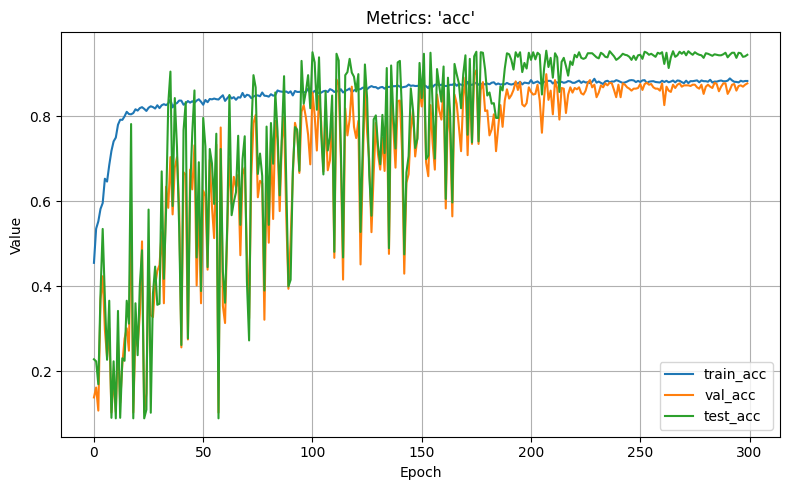

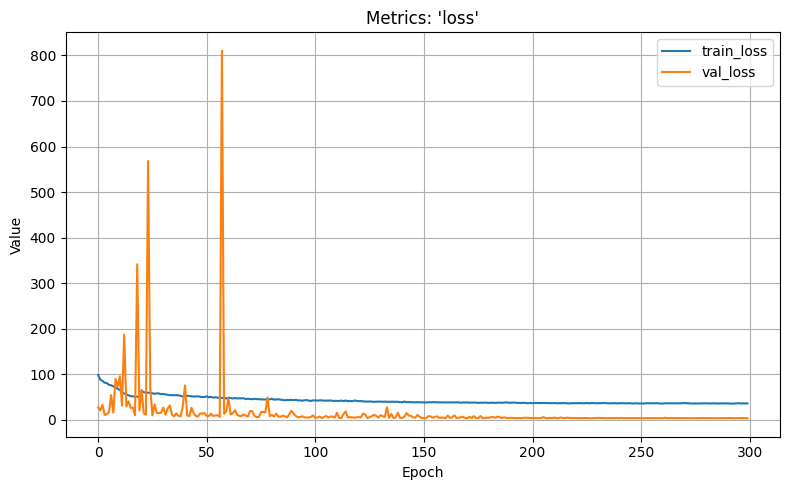

[2026-03-26 10:56:45] [INFO] [MET]: END Session 84


In [43]:
logger.start_session()

logger("Starting training...", tag=BEGIN)
logger("="*60)

logger("Loading dataset...")
PARENT_MODEL_ID = "029"
parent_model_config = json_inter.get_config_by_id(os.path.join(LOGS,"experiments_metadata.json"), PARENT_MODEL_ID)
dataset_path = parent_model_config['dataset_path']
dataset_config = json_inter.get_config_by_id(os.path.join(LOGS, "preprocess_metadata.json"), parent_model_config['dataset_id'])
# dataset_config
# dataset_config = json_inter.get_config_by_id(os.path.join(LOGS, "preprocess_metadata.json"))
data = np.load(dataset_path, allow_pickle=True)

train_X = data["train_X"]
train_y = data["train_y"]
val_X   = data["val_X"]
val_y   = data["val_y"]
test_X  = data["test_X"]
test_y  = data["test_y"]

logger(f"Train: {str(train_X.shape)}", tag=META)
logger(f"Val  : {str(val_X.shape)}", tag=META)
logger(f"Test : {str(test_X.shape)}", tag=META)

logger("Loading parent model...")
parent_model_arch = get_architecture(parent_model_config['model_arch'])
parent_model_name = parent_model_config['model_save_path'] + "\\" + parent_model_config['model_name'] + ".pt"
parent_model = parent_model_arch(dataset_config['window_size'], dataset_config['doppler_bins'], parent_model_config['num_classes'])
parent_model.load_state_dict(torch.load(parent_model_name)['best_model_state_dict'])


logger(dataset_config.__str__(), tag=META)
logger(parent_model_config.__str__(), tag=META)
logger("="*60)



num_classes = len(np.unique(train_y))
CONFIG["num_classes"] = num_classes
CONFIG["parent_model_id"]  = PARENT_MODEL_ID
logger(f"Num Classes: {num_classes}", tag=META)
logger(f"="*60)


os.makedirs(CONFIG["model_save_path"], exist_ok=True)

"""Distillation"""

model, metrics = train_model_distill(
    (train_X, train_y),
    (val_X, val_y),
    (test_X, test_y),
    cnn_distill_d3_2block,
    parent_model
)


logger("\nExecution Complete.", tag=FINISH)


CONFIG['log_session_id'] = logger.get_current_session()
# CONFIG['dataset'] = DATA_CONFIG
json_inter.save_config_to_json(CONFIG, "experiments_metadata")

plot_metrics(metrics, "acc")
plot_metrics(metrics, "loss")

logger.end_session()

### Normal Training:

In [44]:
# logger.start_session()

# logger("Starting training...", tag=BEGIN)
# logger("="*60)
# logger("Loading dataset...")
# logger(DATA_CONFIG.__str__(), tag=META)
# logger(CONFIG.__str__(), tag=META)
# logger("="*60)

# dataset_path = DATA_CONFIG['file_path']

# data = np.load(dataset_path, allow_pickle=True)

# train_X = data["train_X"]
# train_y = data["train_y"]
# val_X   = data["val_X"]
# val_y   = data["val_y"]
# test_X  = data["test_X"]
# test_y  = data["test_y"]

# logger(f"Train: {str(train_X.shape)}", tag=META)
# logger(f"Val  : {str(val_X.shape)}", tag=META)
# logger(f"Test : {str(test_X.shape)}", tag=META)


# num_classes = len(np.unique(train_y))
# CONFIG["num_classes"] = num_classes

# logger(f"Num Classes: {num_classes}", tag=META)
# logger(f"="*60)


# os.makedirs(CONFIG["model_save_path"], exist_ok=True)




# """Normal Training"""
# # model, metrics = train_model(
# #     (train_X, train_y),
# #     (val_X, val_y),
# #     (test_X, test_y),
# #     cnn_lite_v3
# # )

# """QAT Fine-tuning"""
# # float_model_path = os.path.join(CONFIG["model_save_path"],
# #                                 CONFIG["model_name"] + ".pt")
# # float_model_path = "D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Outputs\\Models\\cnn_test_033.pt"

# # model_int8, metrics_int8 = train_model_qat_finetune(
# #     (train_X, train_y),
# #     (val_X, val_y),
# #     (test_X, test_y),
# #     float_model_path,
# #     RadarCNN_GAP_INT8
# # )

# logger("\nExecution Complete.", tag=FINISH)


# CONFIG['log_session_id'] = logger.get_current_session()
# # CONFIG['dataset'] = DATA_CONFIG
# json_inter.save_config_to_json(CONFIG, "experiments_metadata")

# plot_metrics(metrics, "acc")
# plot_metrics(metrics, "loss")

# logger.end_session()

In [51]:
saved_models = json_inter.load_config_as_dataframe("experiments_metadata", fillna_with="N/A")
saved_models
# json_inter.get_config_by_id(LOGS+"\\"+"experiments_metadata.json", "050")

,run_id,dataset_id,batch_size,epochs,learning_rate,use_class_weights,model_name,dataset_path,model_save_path,num_classes,timestamp,size,model_arch,input_dim,log_session_id,best_epoch.epoch,best_epoch.val_acc,best_epoch.test_acc,loss.CrossEntropyLoss.weight,weight_decay,scheduler.learning_rate,scheduler.weight_decay,scheduler.lr_factor,scheduler.lr_patience,scheduler.min_lr,DELTA,loss.CrossEntropyLoss.label_smoothing,parent_model_id,alpha,temperature,nz_alpha_after,Terminated?,Terminated
0,001,009,64,100,0.00100,True,cnn001,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 00:30:22,0.0 MB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,002,011,64,100,0.00100,True,cnn001,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S32_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 00:35:57,0.0 MB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,003,011,64,100,0.00100,True,cnn001,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S32_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 00:35:57,0.0 MB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,004,012,64,100,0.00100,True,cnn001,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB512.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 00:44:57,0.0 MB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,005,012,64,100,0.00100,True,cnn001,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB512.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 00:45:01,0.0 MB,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
5,006,009,64,4,0.00100,True,cnn_test,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 15:00:17,0.0 MB,type,1 x 32 x 256,16.0,1.0,0.727638,0.441824,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
6,007,009,64,4,0.00100,True,cnn_test,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 15:00:31,0.0 MB,type,1 x 32 x 256,16.0,1.0,0.727638,0.441824,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
7,008,009,64,4,0.00100,True,cnn_test_008,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 15:10:03,0.0 MB,type,1 x 32 x 256,17.0,2.0,0.699497,0.471698,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
8,009,009,64,4,0.00100,True,cnn_test_008,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 15:12:23,0.0 MB,type,1 x 32 x 256,17.0,2.0,0.699497,0.471698,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
9,010,009,64,4,0.00100,True,cnn_test_010,D:\Repos\FPGA_Radar_Microdoppler_Classification\Assets\Dataset\Processed\radar_windows_corr_stride_K32_S16_DB256.npz,D:\Repos\FPGA_Radar_Microdoppler_Classification\Outputs\Models,4,2026-02-25 15:27:34,0.0 MB,type,1 x 32 x 256,19.0,2.0,0.846231,0.601415,"tensor([1.2718, 0.6883, 1.1970, 0.8428], device='cuda:0')",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


In [46]:
# json_inter.get_config_by_id(LOGS + "\\"+"experiments_metadata.json", "029")

In [ ]:
def fetch_model_state_dict(run_id, path):
    config = json_inter.get_config_by_id(LOGS + "\\"+"experiments_metadata.json", run_id)
    print(f"Loading model name: {config['model_name']}")
    model_state_dict = torch.load(os.path.join(OUTPUTS, "Models", f"{config['model_name']}.pt"))["best_model_state_dict"]
    return model_state_dict


val_data   = (val_X, val_y)
test_data  = (test_X, test_y)
val_dataset   = RadarDataset(*val_data)
test_dataset  = RadarDataset(*test_data)
input_height = test_data[0].shape[2]
input_width  = test_data[0].shape[3]
num_classes = 4
model = cnn_distill_d3_2block(input_height, input_width, num_classes).to('cuda')
model.load_state_dict(fetch_model_state_dict("059", None))

val_loader = DataLoader(val_dataset,
                        batch_size=CONFIG["batch_size"],
                        shuffle=False)

test_loader = DataLoader(test_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=False)

device = 'cuda'
total = 0
correct = 0
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        # loss = criterion(outputs, y)

        # val_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
val_acc = correct / total

device = 'cuda'
total = 0
correct = 0
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        # loss = criterion(outputs, y)

        # val_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
test_acc = correct / total


val_acc, test_acc

<!--  -->

## ONNX Conversion 

<!-- # def convert_to_onnx(model: nn.Module, out_path: str, input_height: int = 48, input_width: int = 128):
    
#     num_classes = model.fc.out_features
#     model.eval()

#     dummy_input = torch.zeros(1, 1, input_height, input_width)

#     torch.onnx.export(
#         model,
#         dummy_input,
#         out_path,
#         input_names=["input"],
#         output_names=["output"],
#         dynamic_axes=None,
#         opset_version=11,
#         do_constant_folding=True,
#         export_params=True,
#     )
#     print(f"ONNX model saved to: {out_path}")
#     print(f"Fixed input shape:    [1, 1, {input_height}, {input_width}]")
#     print(f"Fixed output shape:   [1, {num_classes}]")


# """
#     Conversion execution
# """

# save_path = os.path.join(OUTPUTS, "For RM V4","cnn_dist.onnx")

# #Load model
# torch_file_path = os.path.join(OUTPUTS, "For RM V4", "cnn_dist_059.pt")
# model = cnn_distill_d3_2block(input_height=48, input_width=128, num_classes=4)
# dctnry = torch.load(torch_file_path)
# model.load_state_dict(dctnry['best_model_state_dict'])
# # torch.save(model.state_dict(), os.path.join(OUTPUTS, "For RM V3","cnn_lite.pt"))
# convert_to_onnx(model, save_path)
# torch.save(dctnry['best_model_state_dict'], os.path.join("cnn_dist_059.pt")) -->